<a href="https://colab.research.google.com/github/TARUNRAGAV/IITD-Tryst-Hackathon/blob/main/STRIKERS_eda_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# =====================================
# 0. Imports & Global Settings
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from scipy import stats

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PALETTE = {0: "#4C72B0", 1: "#DD8452"}  # 0 = legit, 1 = mule


# =====================================
# Helper functions: styling & columns
# =====================================
def set_ax_title(ax, title, subtitle=None):
    ax.set_title(title if subtitle is None else f"{title}\n{subtitle}", fontsize=13, pad=10)


def format_percent_axis(ax):
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


def plot_classwise_kde(df, col, log=False, clip_quantiles=(0.01, 0.99), bw_adjust=1.2):
    """Smooth density plot for a numeric feature, split by is_mule."""
    if "is_mule" not in df.columns or col not in df.columns:
        return
    data = df[[col, "is_mule"]].dropna()
    if data.empty:
        return

    if clip_quantiles is not None:
        lo, hi = data[col].quantile(clip_quantiles)
        data = data[(data[col] >= lo) & (data[col] <= hi)]

    if log:
        data = data[data[col] > 0]
        data[col] = np.log1p(data[col])

    plt.figure(figsize=(6, 4))
    sns.kdeplot(
        data=data,
        x=col,
        hue="is_mule",
        common_norm=False,
        fill=True,
        alpha=0.35,
        palette=PALETTE,
        bw_adjust=bw_adjust,
    )
    scale = " (log1p scale)" if log else ""
    title = f"{col} – class-wise density{scale}"
    set_ax_title(plt.gca(), title)
    plt.tight_layout()
    plt.show()


def standardize_columns(df):
    """Normalize column names across files to consistent snake_case."""
    lower_to_orig = {c.lower(): c for c in df.columns}

    def rename_if_exists(src_lower, target_name):
        if src_lower in lower_to_orig and target_name not in df.columns:
            df.rename(columns={lower_to_orig[src_lower]: target_name}, inplace=True)

    # Generic IDs
    rename_if_exists("accountid", "account_id")
    rename_if_exists("customerid", "customer_id")

    # Labels
    rename_if_exists("ismule", "is_mule")
    rename_if_exists("muleflagdate", "mule_flag_date")
    rename_if_exists("alertreason", "alert_reason")
    rename_if_exists("flaggedbybranch", "flagged_by_branch")

    # Customers
    rename_if_exists("dateofbirth", "date_of_birth")
    rename_if_exists("relationshipstartdate", "relationship_start_date")
    rename_if_exists("panavailable", "pan_available")
    rename_if_exists("aadhaaravailable", "aadhaar_available")
    rename_if_exists("passportavailable", "passport_available")
    rename_if_exists("mobilebankingflag", "mobile_banking_flag")
    rename_if_exists("internetbankingflag", "internet_banking_flag")
    rename_if_exists("atmcardflag", "atm_card_flag")
    rename_if_exists("dematflag", "demat_flag")
    rename_if_exists("creditcardflag", "credit_card_flag")
    rename_if_exists("fastagflag", "fastag_flag")
    rename_if_exists("customerpin", "customer_pin")
    rename_if_exists("permanentpin", "permanent_pin")

    # Accounts
    rename_if_exists("accountstatus", "account_status")
    rename_if_exists("productcode", "product_code")
    rename_if_exists("currencycode", "currency_code")
    rename_if_exists("accountopeningdate", "account_opening_date")
    rename_if_exists("branchcode", "branch_code")
    rename_if_exists("branchpin", "branch_pin")
    rename_if_exists("avgbalance", "avg_balance")
    rename_if_exists("productfamily", "product_family")
    rename_if_exists("nominationflag", "nomination_flag")
    rename_if_exists("chequeallowed", "cheque_allowed")
    rename_if_exists("chequeavailed", "cheque_availed")
    rename_if_exists("numchequebooks", "num_cheque_books")
    rename_if_exists("lastmobileupdatedate", "last_mobile_update_date")
    rename_if_exists("kyccompliant", "kyc_compliant")
    rename_if_exists("lastkycdate", "last_kyc_date")
    rename_if_exists("ruralbranch", "rural_branch")
    rename_if_exists("monthlyavgbalance", "monthly_avg_balance")
    rename_if_exists("quarterlyavgbalance", "quarterly_avg_balance")
    rename_if_exists("dailyavgbalance", "daily_avg_balance")
    rename_if_exists("freezedate", "freeze_date")
    rename_if_exists("unfreezedate", "unfreeze_date")

    # Product details
    rename_if_exists("loansum", "loan_sum")
    rename_if_exists("loancount", "loan_count")
    rename_if_exists("ccsum", "cc_sum")
    rename_if_exists("cccount", "cc_count")
    rename_if_exists("odsum", "od_sum")
    rename_if_exists("odcount", "od_count")
    rename_if_exists("kasum", "ka_sum")
    rename_if_exists("kacount", "ka_count")
    rename_if_exists("sasum", "sa_sum")
    rename_if_exists("sacount", "sa_count")

    # Transactions
    rename_if_exists("transactionid", "transaction_id")
    rename_if_exists("transactiontimestamp", "transaction_timestamp")
    rename_if_exists("mcccode", "mcc_code")
    rename_if_exists("txntype", "txn_type")
    rename_if_exists("counterpartyid", "counterparty_id")

    return df



In [45]:
# =====================================
# 1. Load CSVs (upload all to Colab first)
# =====================================
customers = pd.read_csv("customers.csv")
accounts = pd.read_csv("accounts.csv")
linkage = pd.read_csv("customer_account_linkage.csv")
products = pd.read_csv("product_details.csv")
train_labels = pd.read_csv("train_labels.csv")
test_accounts = pd.read_csv("test_accounts.csv")

txn_parts = []
for i in range(6):
    fname = f"transactions_part_{i}.csv"
    try:
        part = pd.read_csv(fname)
        txn_parts.append(part)
        print(f"Loaded {fname} with shape {part.shape}")
    except FileNotFoundError:
        print(f"WARNING: {fname} not found; skipping.")

transactions = pd.concat(txn_parts, ignore_index=True) if txn_parts else None
print("transactions shape:", None if transactions is None else transactions.shape)



Loaded transactions_part_0.csv with shape (1237474, 8)
Loaded transactions_part_1.csv with shape (1237474, 8)
Loaded transactions_part_2.csv with shape (1237474, 8)
Loaded transactions_part_3.csv with shape (1237474, 8)
Loaded transactions_part_4.csv with shape (1237474, 8)
Loaded transactions_part_5.csv with shape (1237475, 8)
transactions shape: (7424845, 8)


In [46]:
# =====================================
# 2. Standardise columns across tables
# =====================================
customers = standardize_columns(customers)
accounts = standardize_columns(accounts)
linkage = standardize_columns(linkage)
products = standardize_columns(products)
train_labels = standardize_columns(train_labels)
test_accounts = standardize_columns(test_accounts)
if transactions is not None:
    transactions = standardize_columns(transactions)


In [47]:
# =====================================
# 3. Quick overview of each table
# =====================================
def quick_overview(name, df, n_head=3):
    print("\n" + "="*90)
    print(f"{name}  | shape = {df.shape}")
    print("\nSample rows:")
    display(df.head(n_head))
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values (count):")
    print(df.isna().sum())
    print("\nMissing values (rate, %):")
    print((df.isna().mean() * 100).round(2))

tables = {
    "customers": customers,
    "accounts": accounts,
    "customer_account_linkage": linkage,
    "product_details": products,
    "train_labels": train_labels,
    "test_accounts": test_accounts,
}
if transactions is not None:
    tables["transactions"] = transactions

for name, df in tables.items():
    quick_overview(name, df)




customers  | shape = (39988, 14)

Sample rows:


,customer_id,date_of_birth,relationship_start_date,pan_available,aadhaar_available,passport_available,mobile_banking_flag,internet_banking_flag,atm_card_flag,demat_flag,credit_card_flag,fastag_flag,customer_pin,permanent_pin
0,CUST_000001,1992-12-26,2008-04-09,Y,Y,N,Y,Y,Y,N,Y,N,613004,613004
1,CUST_000006,1950-05-01,2005-08-01,Y,Y,N,Y,N,Y,N,N,Y,400106,400106
2,CUST_000041,1992-01-01,2013-11-22,NaN,N,N,Y,Y,N,N,N,N,700152,700152



Dtypes:
customer_id                object
date_of_birth              object
relationship_start_date    object
pan_available              object
aadhaar_available          object
passport_available         object
mobile_banking_flag        object
internet_banking_flag      object
atm_card_flag              object
demat_flag                 object
credit_card_flag           object
fastag_flag                object
customer_pin                int64
permanent_pin               int64
dtype: object

Missing values (count):
customer_id                   0
date_of_birth                 0
relationship_start_date       0
pan_available              5732
aadhaar_available          9708
passport_available            0
mobile_banking_flag           0
internet_banking_flag         0
atm_card_flag                 0
demat_flag                    0
credit_card_flag              0
fastag_flag                   0
customer_pin                  0
permanent_pin                 0
dtype: int64

Missing values

,account_id,account_status,product_code,currency_code,account_opening_date,branch_code,branch_pin,avg_balance,product_family,nomination_flag,cheque_allowed,cheque_availed,num_chequebooks,last_mobile_update_date,kyc_compliant,last_kyc_date,rural_branch,monthly_avg_balance,quarterly_avg_balance,daily_avg_balance,freeze_date,unfreeze_date
0,ACCT_000001,active,100,1,2023-04-25,8229,"613,004.0000","1,526.0100",S,N,Y,N,0,NaN,N,2022-04-13,N,"1,663.3100","1,830.6900","1,950.1300",NaN,NaN
1,ACCT_000006,active,1133,1,2021-07-01,6076,"400,106.0000","-1,048.8200",O,N,N,N,0,NaN,Y,2022-04-12,N,-910.0100,"-1,136.4800","-1,208.5400",NaN,NaN
2,ACCT_000041,active,100,1,2023-07-26,3756,"110,128.0000",0.0000,S,N,Y,N,0,NaN,Y,2023-02-07,N,0.0000,0.0000,0.0000,NaN,NaN



Dtypes:
account_id                  object
account_status              object
product_code                 int64
currency_code                int64
account_opening_date        object
branch_code                  int64
branch_pin                 float64
avg_balance                float64
product_family              object
nomination_flag             object
cheque_allowed              object
cheque_availed              object
num_chequebooks              int64
last_mobile_update_date     object
kyc_compliant               object
last_kyc_date               object
rural_branch                object
monthly_avg_balance        float64
quarterly_avg_balance      float64
daily_avg_balance          float64
freeze_date                 object
unfreeze_date               object
dtype: object

Missing values (count):
account_id                     0
account_status                 0
product_code                   0
currency_code                  0
account_opening_date           0
branch_code      

...


Dtypes:
account_id            object
is_mule                int64
mule_flag_date        object
alert_reason          object
flagged_by_branch    float64
dtype: object

Missing values (count):
account_id               0
is_mule                  0
mule_flag_date       23760
alert_reason         23781
flagged_by_branch    23760
dtype: int64

Missing values (rate, %):
account_id           0.0000
is_mule              0.0000
mule_flag_date      98.9100
alert_reason        98.9900
flagged_by_branch   98.9100
dtype: float64

test_accounts  | shape = (16015, 1)

Sample rows:


,account_id
0,ACCT_027260
1,ACCT_119686
2,ACCT_065257



Dtypes:
account_id    object
dtype: object

Missing values (count):
account_id    0
dtype: int64

Missing values (rate, %):
account_id   0.0000
dtype: float64

transactions  | shape = (7424845, 8)

Sample rows:


,transaction_id,account_id,transaction_timestamp,mcc_code,channel,amount,txn_type,counterparty_id
0,TXN_32358649,ACCT_177174,2020-07-01T00:10:03,5651,END,"18,000.0000",D,CP_005826
1,TXN_15222199,ACCT_082915,2020-07-01T00:24:11,9355,IPM,"15,306.2200",D,CP_071766
2,TXN_15349994,ACCT_083481,2020-07-01T00:38:08,6501,UPD,"1,000.0000",C,CP_004566



Dtypes:
transaction_id            object
account_id                object
transaction_timestamp     object
mcc_code                   int64
channel                   object
amount                   float64
txn_type                  object
counterparty_id           object
dtype: object

Missing values (count):
transaction_id           0
account_id               0
transaction_timestamp    0
mcc_code                 0
channel                  0
amount                   0
txn_type                 0
counterparty_id          0
dtype: int64

Missing values (rate, %):
transaction_id          0.0000
account_id              0.0000
transaction_timestamp   0.0000
mcc_code                0.0000
channel                 0.0000
amount                  0.0000
txn_type                0.0000
counterparty_id         0.0000
dtype: float64


In [48]:
# =====================================
# 4. Build joined train_view & test_view
# =====================================
assert "account_id" in accounts.columns
assert "account_id" in train_labels.columns
assert "customer_id" in customers.columns
assert {"account_id", "customer_id"}.issubset(linkage.columns)

train_view = (
    train_labels
    .merge(accounts, on="account_id", how="left", validate="1:1")
    .merge(linkage, on="account_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="customer_id", how="left")
)

print("train_view shape:", train_view.shape)
display(train_view.head())

test_view = (
    test_accounts
    .merge(accounts, on="account_id", how="left")
    .merge(linkage, on="account_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="customer_id", how="left")
)

print("test_view shape:", test_view.shape)
display(test_view.head())


train_view shape: (24023, 50)


,account_id,is_mule,mule_flag_date,alert_reason,flagged_by_branch,account_status,product_code,currency_code,account_opening_date,branch_code,branch_pin,avg_balance,product_family,nomination_flag,cheque_allowed,cheque_availed,num_chequebooks,last_mobile_update_date,kyc_compliant,last_kyc_date,rural_branch,monthly_avg_balance,quarterly_avg_balance,daily_avg_balance,freeze_date,unfreeze_date,customer_id,date_of_birth,relationship_start_date,pan_available,aadhaar_available,passport_available,mobile_banking_flag,internet_banking_flag,atm_card_flag,demat_flag,credit_card_flag,fastag_flag,customer_pin,permanent_pin,loan_sum,loan_count,cc_sum,cc_count,od_sum,od_count,ka_sum,ka_count,sa_sum,sa_count
0,ACCT_023272,0,NaN,NaN,NaN,active,1102,1,2023-08-03,2995,"360,048.0000",0.0000,K,N,Y,N,0,NaN,Y,2022-03-09,N,0.0000,0.0000,0.0000,NaN,NaN,CUST_023208,1984-06-27,2012-08-24,Y,Y,N,N,N,N,N,N,N,360048,360048,"-247,847.5100",1,NaN,0,0.0000,0,0.0000,1,0.0000,0
1,ACCT_062177,0,NaN,NaN,NaN,active,804,1,2023-08-17,1898,"250,038.0000","-15,597.3900",O,N,N,N,0,NaN,Y,2022-01-22,N,"-16,731.6700","-11,584.8600","-16,182.2100",NaN,NaN,CUST_061997,1981-09-26,2009-08-25,Y,N,N,Y,N,N,N,Y,Y,250038,250038,NaN,0,"-77,536.2400",2,"-46,260.4900",1,0.0000,0,0.0000,0
2,ACCT_194388,0,NaN,NaN,NaN,active,1133,1,2023-11-23,2169,"700,076.0000","46,928.8500",O,N,N,N,0,NaN,Y,2022-10-03,N,"43,216.1400","49,917.8700","39,254.0300",NaN,NaN,CUST_193804,1962-04-25,2019-02-16,Y,NaN,N,Y,N,N,N,N,N,700076,700076,NaN,0,NaN,0,"-44,988.3900",1,0.0000,0,0.0000,0
3,ACCT_064626,0,NaN,NaN,NaN,active,187,1,2017-06-25,6728,"400,078.0000","46,805.9300",S,Y,Y,N,0,NaN,Y,2023-06-20,N,"51,012.2000","38,443.7000","65,875.4700",NaN,NaN,CUST_064439,1957-05-28,2010-02-03,Y,N,N,N,N,Y,N,N,N,110134,110134,NaN,0,NaN,0,0.0000,0,0.0000,0,"46,805.9300",1
4,ACCT_063119,0,NaN,NaN,NaN,active,200,1,2023-04-05,1550,"176,038.0000",736.2800,K,Y,Y,N,0,NaN,Y,2023-03-18,N,810.9000,755.7100,637.5200,NaN,NaN,CUST_062937,1992-07-09,2023-06-14,NaN,Y,Y,Y,Y,Y,N,N,N,834022,500028,NaN,0,NaN,0,0.0000,0,736.2800,1,0.0000,0


test_view shape: (16015, 46)


,account_id,account_status,product_code,currency_code,account_opening_date,branch_code,branch_pin,avg_balance,product_family,nomination_flag,cheque_allowed,cheque_availed,num_chequebooks,last_mobile_update_date,kyc_compliant,last_kyc_date,rural_branch,monthly_avg_balance,quarterly_avg_balance,daily_avg_balance,freeze_date,unfreeze_date,customer_id,date_of_birth,relationship_start_date,pan_available,aadhaar_available,passport_available,mobile_banking_flag,internet_banking_flag,atm_card_flag,demat_flag,credit_card_flag,fastag_flag,customer_pin,permanent_pin,loan_sum,loan_count,cc_sum,cc_count,od_sum,od_count,ka_sum,ka_count,sa_sum,sa_count
0,ACCT_027260,active,200,1,2023-02-21,9853,"530,052.0000",245.5800,K,Y,Y,N,0,NaN,Y,2021-10-27,N,281.7500,175.9300,317.7200,NaN,NaN,CUST_027183,1985-10-06,2020-06-21,Y,N,N,N,N,N,N,N,N,530052,530052,"-618,859.7300",2,NaN,0,0.0000,0,245.5800,1,0.0000,0
1,ACCT_119686,active,193,1,2021-01-04,5815,NaN,78.2300,K,Y,Y,N,0,NaN,Y,2023-01-07,N,76.1100,57.4800,60.8200,NaN,NaN,CUST_119330,1988-08-22,2017-02-09,Y,NaN,N,N,N,N,N,N,N,250002,250002,NaN,0,NaN,0,0.0000,0,78.2300,1,0.0000,0
2,ACCT_065257,active,100,1,2024-07-17,4224,"122,015.0000","219,752.0700",S,Y,Y,N,0,NaN,Y,2024-11-10,N,"229,056.9900","253,214.0400","157,009.9800",NaN,NaN,CUST_065068,2006-10-22,2002-01-03,Y,N,N,Y,N,Y,N,N,N,760036,760036,"-227,091.0700",2,NaN,0,0.0000,0,0.0000,0,"219,752.0700",1
3,ACCT_118031,active,193,1,2023-01-01,5426,"625,076.0000","-16,521.4300",K,N,Y,Y,0,NaN,Y,2022-04-08,Y,"-16,411.7500","-14,759.0400","-11,856.8400",NaN,NaN,CUST_117680,1982-03-10,2003-10-19,Y,N,N,Y,Y,N,N,N,N,625076,620028,"-114,530.9700",1,NaN,0,0.0000,0,"-16,521.4300",1,0.0000,0
4,ACCT_141657,active,1102,1,2023-07-09,7467,"500,085.0000","246,164.7300",K,N,Y,Y,1,NaN,Y,2024-04-18,N,"279,444.6400","274,820.7900","269,392.5000",NaN,NaN,CUST_141233,2004-06-12,2012-06-01,Y,Y,N,Y,N,Y,N,N,N,500085,500085,"-1,409,139.0600",2,NaN,0,0.0000,0,"246,164.7300",1,0.0000,0


In [49]:
# =====================================
# 5. Core time features (age, tenure, account age)
# =====================================
REF_DATE = pd.to_datetime("2025-06-30")

def add_core_time_features(df):
    if "relationship_start_date" in df.columns:
        df["relationship_start_date"] = pd.to_datetime(df["relationship_start_date"], errors="coerce")
        df["rel_tenure_days"] = (REF_DATE - df["relationship_start_date"]).dt.days

    if "date_of_birth" in df.columns:
        df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")
        df["age_years"] = (REF_DATE - df["date_of_birth"]).dt.days / 365.25

    if "account_opening_date" in df.columns:
        df["account_opening_date"] = pd.to_datetime(df["account_opening_date"], errors="coerce")
        df["account_age_days"] = (REF_DATE - df["account_opening_date"]).dt.days

    for col in ["last_kyc_date", "last_mobile_update_date", "freeze_date", "unfreeze_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    return df

train_view = add_core_time_features(train_view)
test_view = add_core_time_features(test_view)



is_mule value counts:
 is_mule
0    23760
1      263
Name: count, dtype: int64

Mule rate: 1.0948%


/tmp/ipython-input-2017212281.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


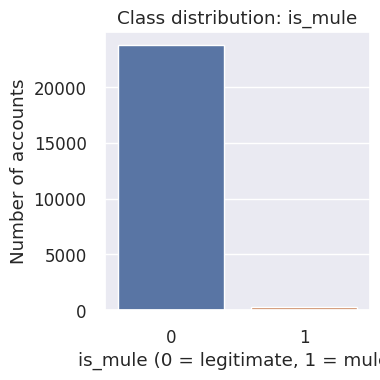

In [50]:
# =====================================
# 6. Target distribution & class imbalance
# =====================================

mule_counts = train_labels["is_mule"].value_counts().sort_index()
mule_rate = train_labels["is_mule"].mean()

print("is_mule value counts:\n", mule_counts)
print(f"\nMule rate: {mule_rate:.4%}")

# Simple, robust barplot without custom palette dict
plt.figure(figsize=(4, 4))
sns.barplot(
    x=mule_counts.index.astype(str),
    y=mule_counts.values,
    palette=["#4C72B0", "#DD8452"]  # colors in order for 0 and 1
)
plt.xlabel("is_mule (0 = legitimate, 1 = mule)")
plt.ylabel("Number of accounts")
plt.title("Class distribution: is_mule")
plt.tight_layout()
plt.show()



/tmp/ipython-input-1858173569.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


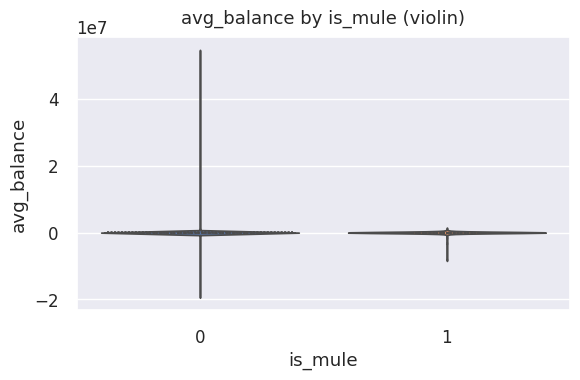

/tmp/ipython-input-1858173569.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


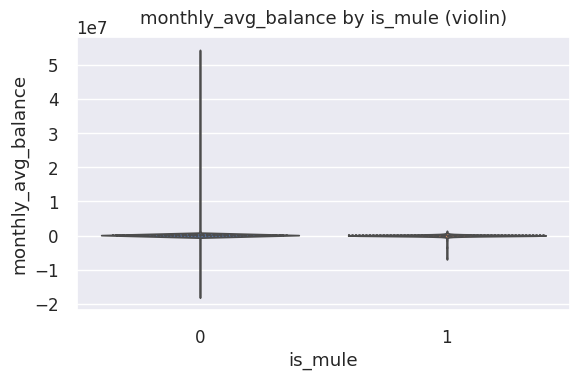

/tmp/ipython-input-1858173569.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


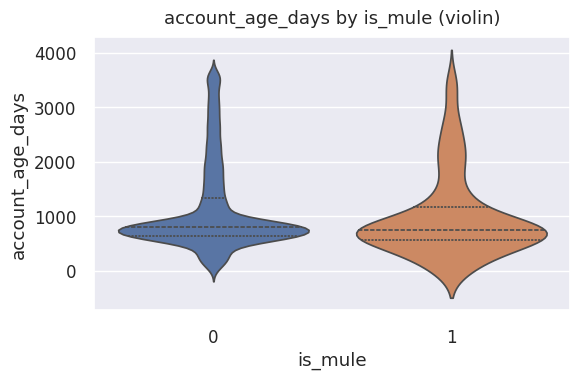

/tmp/ipython-input-1858173569.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


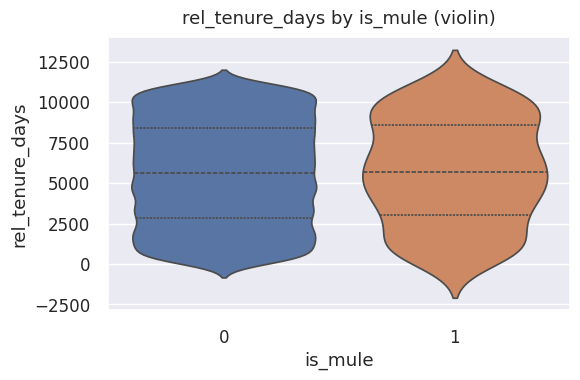

/tmp/ipython-input-1858173569.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


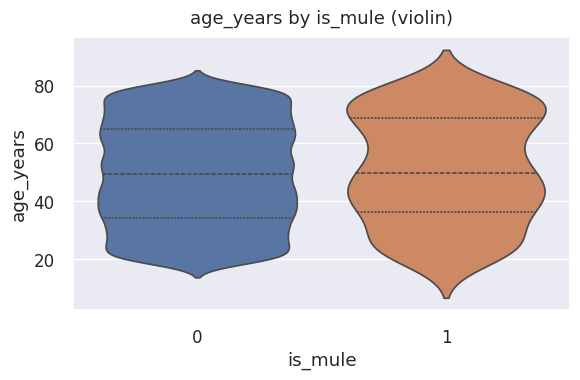

In [51]:
# =====================================
# 7. Account-level EDA – numeric (violin, log-hists, KDE)
# =====================================
violin_cols = [
    "avg_balance", "monthly_avg_balance",
    "account_age_days", "rel_tenure_days", "age_years"
]
violin_cols = [c for c in violin_cols if c in train_view.columns]

# Create a local palette with string keys to match seaborn's expectation
# for categorical x-axis labels when they are integers
string_keyed_palette = {str(k): v for k, v in PALETTE.items()}

for col in violin_cols:
    plt.figure(figsize=(6, 4))
    sns.violinplot(
        data=train_view,
        x="is_mule",
        y=col,
        inner="quartile",
        palette=string_keyed_palette # Use the string-keyed palette
    )
    set_ax_title(plt.gca(), f"{col} by is_mule (violin)")
    plt.tight_layout()
    plt.show()

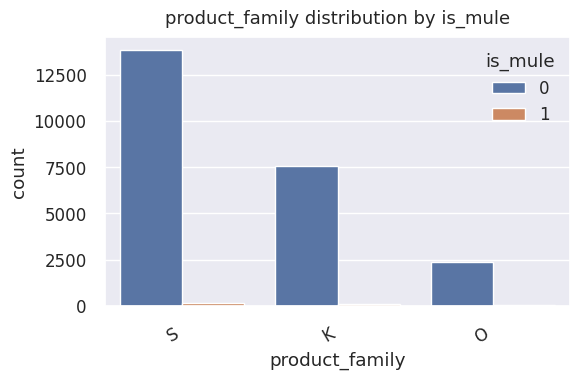

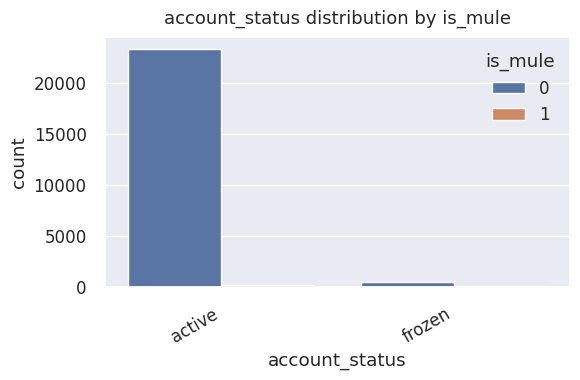

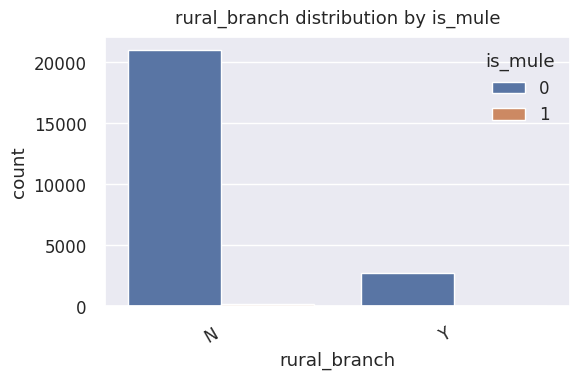

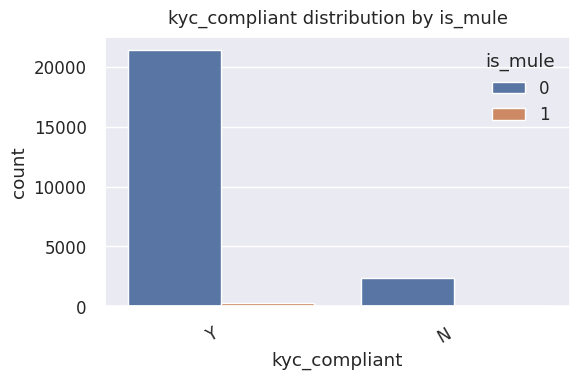

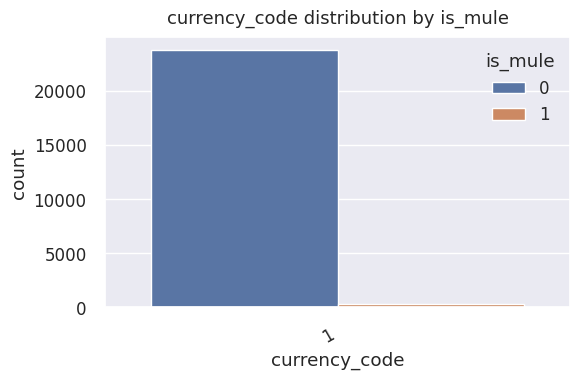

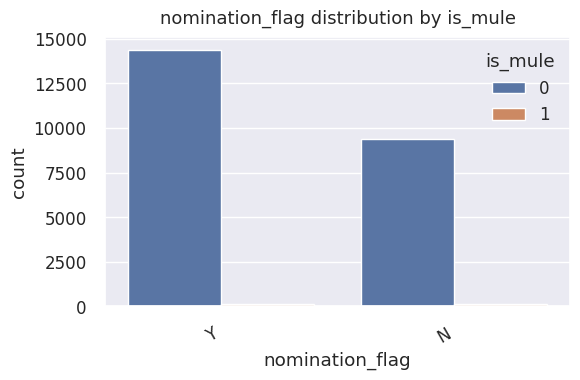

In [52]:
# =====================================
# 8. Account-level EDA – categorical
# =====================================
cat_cols = [
    "product_family", "account_status",
    "rural_branch", "kyc_compliant",
    "currency_code", "nomination_flag"
]
cat_cols = [c for c in cat_cols if c in train_view.columns]

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=train_view,
        x=col, hue="is_mule",
        palette=PALETTE,
        order=train_view[col].value_counts().index
    )
    plt.xticks(rotation=30, ha="right")
    set_ax_title(plt.gca(), f"{col} distribution by is_mule")
    plt.tight_layout()
    plt.show()


is_mule,0,1
ka_sum,"19,879.4813","-4,977.6375"
sa_sum,"17,649.2465","21,283.8258"
sa_count,0.5886,0.8175
loan_count,0.4285,0.4639
ka_count,0.3211,0.3384
cc_count,0.2373,0.2738
od_count,0.1013,0.1027
od_sum,"-7,769.5290","-11,092.6840"
cc_sum,"-81,642.2776","-108,337.7349"
loan_sum,"-720,499.8513","-777,454.0145"


<Figure size 1000x600 with 0 Axes>

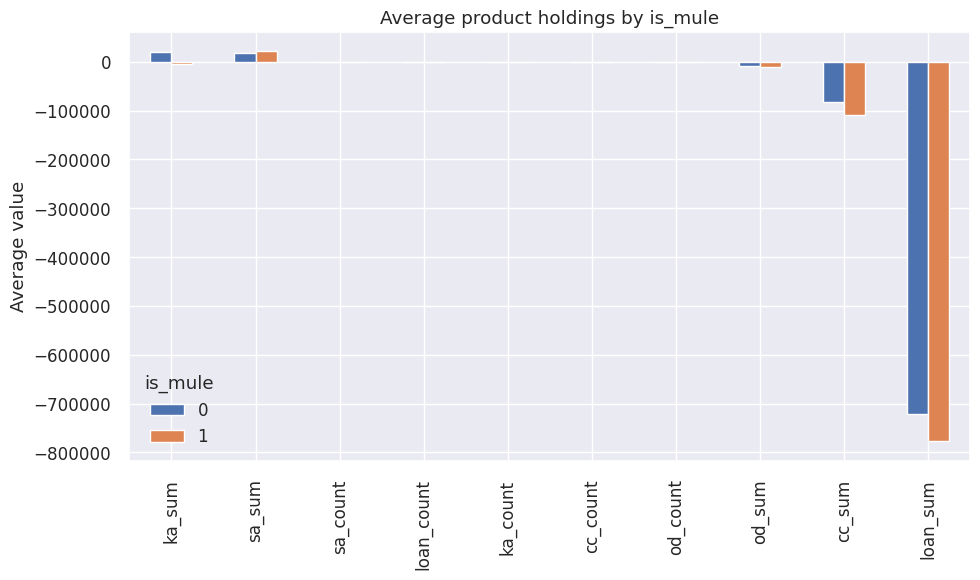

/tmp/ipython-input-208485640.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


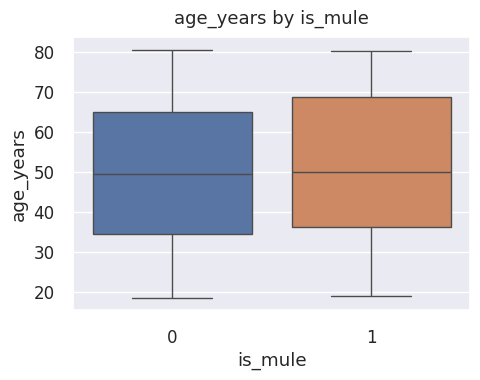

/tmp/ipython-input-208485640.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


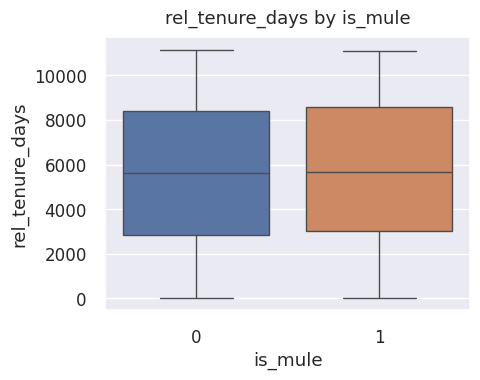

In [54]:
# =====================================
# 9. Customer-level & product holdings EDA
# =====================================
prod_cols = [
    "loan_sum", "loan_count",
    "cc_sum", "cc_count",
    "od_sum", "od_count",
    "ka_sum", "ka_count",
    "sa_sum", "sa_count"
]
prod_cols = [c for c in prod_cols if c in train_view.columns]

if prod_cols:
    customer_stats = (
        train_view[["is_mule"] + prod_cols]
        .groupby("is_mule")
        .mean()
        .T
        .sort_values(by=0, ascending=False)
    )
    display(customer_stats)

    plt.figure(figsize=(10, 6))
    customer_stats.plot(kind="bar", figsize=(10, 6))
    plt.ylabel("Average value")
    plt.title("Average product holdings by is_mule")
    plt.tight_layout()
    plt.show()

# Create a local palette with string keys to match seaborn's expectation
# for categorical x-axis labels when they are integers
string_keyed_palette = {str(k): v for k, v in PALETTE.items()}

for col in ["age_years", "rel_tenure_days"]:
    if col not in train_view.columns:
        continue
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=train_view,
        x="is_mule", y=col,
        showfliers=False, palette=string_keyed_palette
    )
    set_ax_title(plt.gca(), f"{col} by is_mule")
    plt.tight_layout()
    plt.show()


In [55]:
# =====================================
# 10. Transaction-level aggregation to per-account
# =====================================
if transactions is not None:
    transactions["transaction_timestamp"] = pd.to_datetime(
        transactions["transaction_timestamp"], errors="coerce"
    )

    def credit_sum(x):
        mask = transactions.loc[x.index, "txn_type"] == "C"
        return x[mask].sum()

    def debit_sum(x):
        mask = transactions.loc[x.index, "txn_type"] == "D"
        return x[mask].sum()

    txn_agg = (
        transactions
        .groupby("account_id")
        .agg(
            txn_count=("transaction_id", "nunique"),
            total_amount=("amount", "sum"),
            avg_amount=("amount", "mean"),
            credit_amount=("amount", credit_sum),
            debit_amount=("amount", debit_sum),
            unique_counterparties=("counterparty_id", "nunique"),
            first_txn=("transaction_timestamp", "min"),
            last_txn=("transaction_timestamp", "max"),
        )
        .reset_index()
    )

    txn_agg["active_days"] = (
        txn_agg["last_txn"] - txn_agg["first_txn"]
    ).dt.days

    train_txn = train_view.merge(txn_agg, on="account_id", how="left")
else:
    train_txn = train_view.copy()

print("train_txn shape:", train_txn.shape)
display(train_txn.head())



train_txn shape: (24023, 62)


,account_id,is_mule,mule_flag_date,alert_reason,flagged_by_branch,account_status,product_code,currency_code,account_opening_date,branch_code,branch_pin,avg_balance,product_family,nomination_flag,cheque_allowed,cheque_availed,num_chequebooks,last_mobile_update_date,kyc_compliant,last_kyc_date,rural_branch,monthly_avg_balance,quarterly_avg_balance,daily_avg_balance,freeze_date,unfreeze_date,customer_id,date_of_birth,relationship_start_date,pan_available,aadhaar_available,passport_available,mobile_banking_flag,internet_banking_flag,atm_card_flag,demat_flag,credit_card_flag,fastag_flag,customer_pin,permanent_pin,loan_sum,loan_count,cc_sum,cc_count,od_sum,od_count,ka_sum,ka_count,sa_sum,sa_count,rel_tenure_days,age_years,account_age_days,txn_count,total_amount,avg_amount,credit_amount,debit_amount,unique_counterparties,first_txn,last_txn,active_days
0,ACCT_023272,0,NaN,NaN,NaN,active,1102,1,2023-08-03,2995,"360,048.0000",0.0000,K,N,Y,N,0,NaT,Y,2022-03-09,N,0.0000,0.0000,0.0000,NaT,NaT,CUST_023208,1984-06-27,2012-08-24,Y,Y,N,N,N,N,N,N,N,360048,360048,"-247,847.5100",1,NaN,0,0.0000,0,0.0000,1,0.0000,0,4693,41.0075,697,10.0000,"41,605.8400","4,160.5840","41,630.1900",-24.3500,9.0000,2023-10-03 14:08:10,2025-06-08 17:10:29,614.0000
1,ACCT_062177,0,NaN,NaN,NaN,active,804,1,2023-08-17,1898,"250,038.0000","-15,597.3900",O,N,N,N,0,NaT,Y,2022-01-22,N,"-16,731.6700","-11,584.8600","-16,182.2100",NaT,NaT,CUST_061997,1981-09-26,2009-08-25,Y,N,N,Y,N,N,N,Y,Y,250038,250038,NaN,0,"-77,536.2400",2,"-46,260.4900",1,0.0000,0,0.0000,0,5788,43.7591,683,162.0000,"1,223,424.4000","7,552.0025","799,143.7700","424,280.6300",13.0000,2023-08-31 19:11:35,2025-06-21 14:49:54,659.0000
2,ACCT_194388,0,NaN,NaN,NaN,active,1133,1,2023-11-23,2169,"700,076.0000","46,928.8500",O,N,N,N,0,NaT,Y,2022-10-03,N,"43,216.1400","49,917.8700","39,254.0300",NaT,NaT,CUST_193804,1962-04-25,2019-02-16,Y,NaN,N,Y,N,N,N,N,N,700076,700076,NaN,0,NaN,0,"-44,988.3900",1,0.0000,0,0.0000,0,2326,63.1814,585,4.0000,"9,717.8300","2,429.4575","3,379.3300","6,338.5000",3.0000,2023-12-16 23:51:27,2025-05-17 19:15:02,517.0000
3,ACCT_064626,0,NaN,NaN,NaN,active,187,1,2017-06-25,6728,"400,078.0000","46,805.9300",S,Y,Y,N,0,NaT,Y,2023-06-20,N,"51,012.2000","38,443.7000","65,875.4700",NaT,NaT,CUST_064439,1957-05-28,2010-02-03,Y,N,N,N,N,Y,N,N,N,110134,110134,NaN,0,NaN,0,0.0000,0,0.0000,0,"46,805.9300",1,5626,68.0903,2927,72.0000,"1,571,544.1700","21,827.0024","877,204.0200","694,340.1500",38.0000,2020-07-01 11:54:00,2025-06-17 09:37:23,"1,811.0000"
4,ACCT_063119,0,NaN,NaN,NaN,active,200,1,2023-04-05,1550,"176,038.0000",736.2800,K,Y,Y,N,0,NaT,Y,2023-03-18,N,810.9000,755.7100,637.5200,NaT,NaT,CUST_062937,1992-07-09,2023-06-14,NaN,Y,Y,Y,Y,Y,N,N,N,834022,500028,NaN,0,NaN,0,0.0000,0,736.2800,1,0.0000,0,747,32.9747,817,"1,057.0000","9,094,279.8700","8,603.8599","4,161,706.7900","4,932,573.0800",11.0000,2023-04-05 09:33:44,2025-06-24 20:28:43,811.0000


In [56]:
# =====================================
# 11. Pattern-inspired features (structuring, velocity, fan-in/out, round amounts)
# =====================================
if transactions is not None:
    # Days since last txn
    train_txn["days_since_last_txn"] = (REF_DATE - train_txn["last_txn"]).dt.days

    # Velocity
    train_txn["txn_velocity_per_day"] = (
        train_txn["txn_count"] / train_txn["active_days"].replace(0, np.nan)
    )

    # Structuring share: fraction of txns in [45k, 50k)
    def structuring_share_group(df):
        amt = df["amount"]
        return ((amt >= 45000) & (amt < 50000)).mean()

    struct_df = (
        transactions
        .groupby("account_id")
        .apply(structuring_share_group)
        .reset_index(name="structuring_share")
    )
    train_txn = train_txn.merge(struct_df, on="account_id", how="left")

    # Credit / debit ratio
    train_txn["credit_debit_ratio"] = (
        train_txn["credit_amount"].abs() / train_txn["debit_amount"].abs().replace(0, np.nan)
    )

    # Round-amount share (multiples of 1k, 5k, 10k, 50k)
    round_bases = [1000, 5000, 10000, 50000]

    def round_share_group(df):
        amt = df["amount"].abs()
        is_round = False
        for base in round_bases:
            is_round = is_round | (amt % base == 0)
        return is_round.mean()

    round_df = (
        transactions
        .groupby("account_id")
        .apply(round_share_group)
        .reset_index(name="round_amount_share")
    )
    train_txn = train_txn.merge(round_df, on="account_id", how="left")

print("Pattern features ready:",
      [c for c in ["txn_velocity_per_day", "structuring_share", "credit_debit_ratio", "round_amount_share"]
       if c in train_txn.columns])


/tmp/ipython-input-1031376523.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(structuring_share_group)


Pattern features ready: ['txn_velocity_per_day', 'structuring_share', 'credit_debit_ratio', 'round_amount_share']


/tmp/ipython-input-1031376523.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(round_share_group)


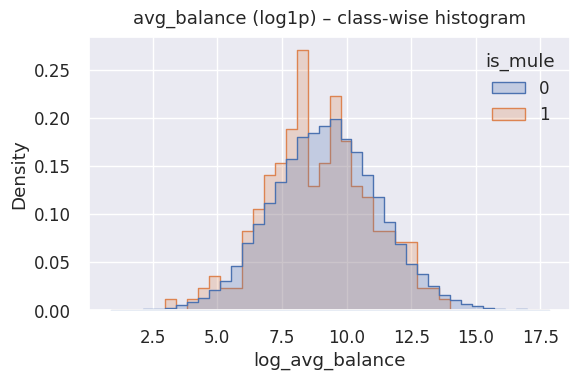

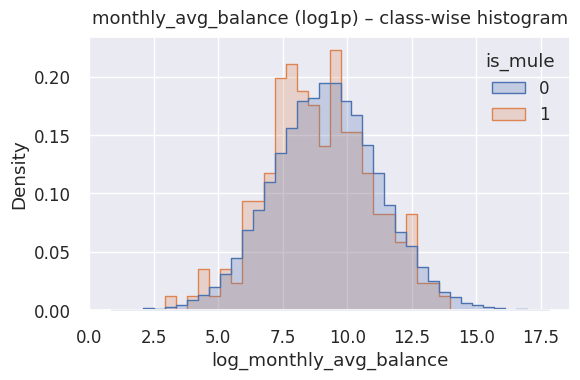

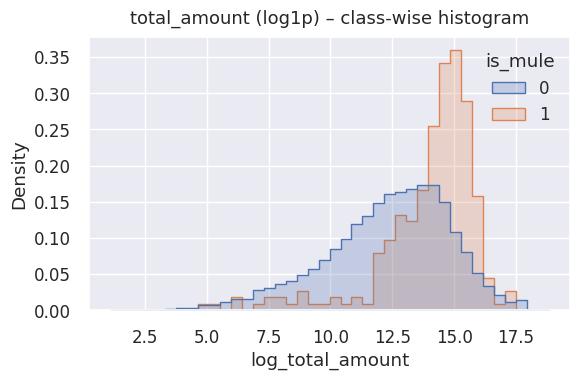

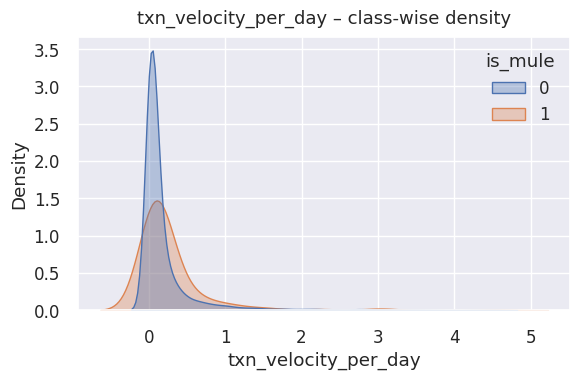

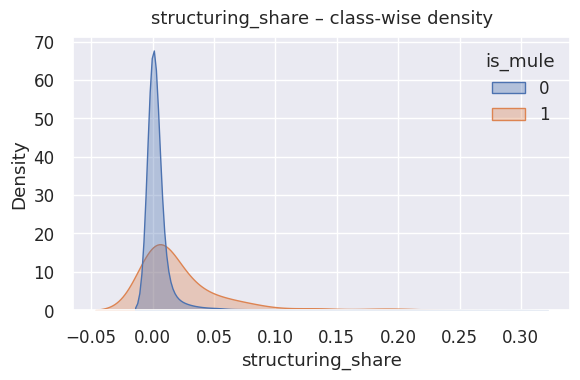

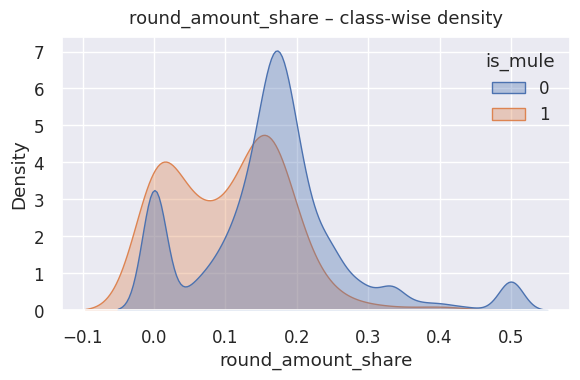

In [57]:
# =====================================
# 12. Rich numeric visuals (log hist, KDE) for key features
# =====================================
# Log-scale histograms for highly skewed money features
money_cols = ["avg_balance", "monthly_avg_balance", "total_amount"]
money_cols = [c for c in money_cols if c in train_txn.columns]

for col in money_cols:
    data = train_txn[["is_mule", col]].dropna()
    data = data[data[col] > 0]
    data["log_" + col] = np.log1p(data[col])

    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=data,
        x="log_" + col,
        hue="is_mule",
        element="step",
        stat="density",
        common_norm=False,
        palette=PALETTE,
        bins=40
    )
    set_ax_title(plt.gca(), f"{col} (log1p) – class-wise histogram")
    plt.tight_layout()
    plt.show()

# KDE for behavioural pattern features
for col in ["txn_velocity_per_day", "structuring_share", "round_amount_share"]:
    if col in train_txn.columns:
        plot_classwise_kde(train_txn, col, log=False, clip_quantiles=(0.01, 0.99))



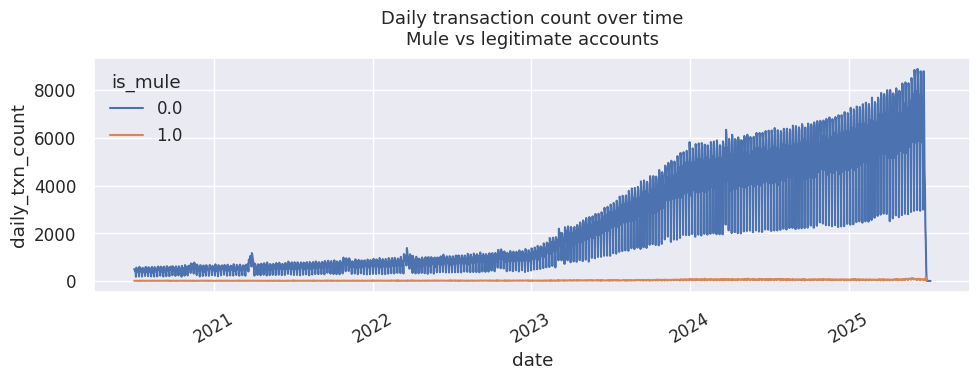

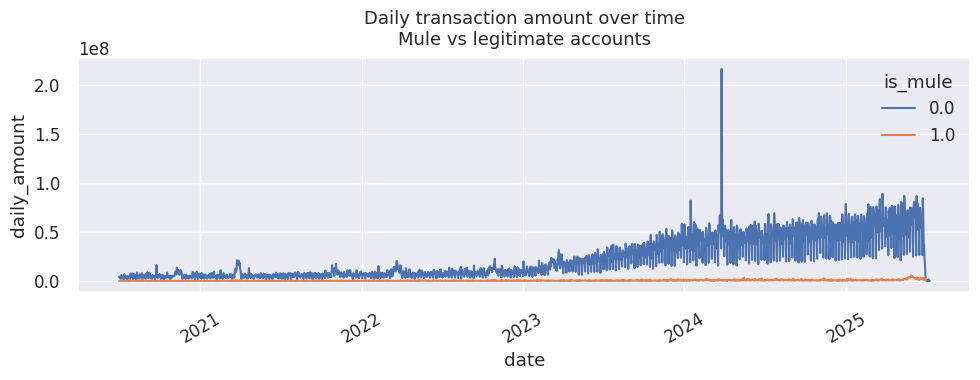

In [58]:
# =====================================
# 13. Temporal behaviour – daily patterns
# =====================================
if transactions is not None:
    tx = transactions.merge(
        train_labels[["account_id", "is_mule"]],
        on="account_id", how="left"
    )
    tx["transaction_timestamp"] = pd.to_datetime(tx["transaction_timestamp"], errors="coerce")
    tx["date"] = tx["transaction_timestamp"].dt.date

    daily_agg = (
        tx.groupby(["date", "is_mule"])
        .agg(
            daily_txn_count=("transaction_id", "nunique"),
            daily_amount=("amount", "sum"),
        )
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=daily_agg.dropna(subset=["is_mule"]),
        x="date", y="daily_txn_count", hue="is_mule",
        palette=PALETTE
    )
    plt.xticks(rotation=30)
    set_ax_title(plt.gca(), "Daily transaction count over time", "Mule vs legitimate accounts")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=daily_agg.dropna(subset=["is_mule"]),
        x="date", y="daily_amount", hue="is_mule",
        palette=PALETTE
    )
    plt.xticks(rotation=30)
    set_ax_title(plt.gca(), "Daily transaction amount over time", "Mule vs legitimate accounts")
    plt.tight_layout()
    plt.show()



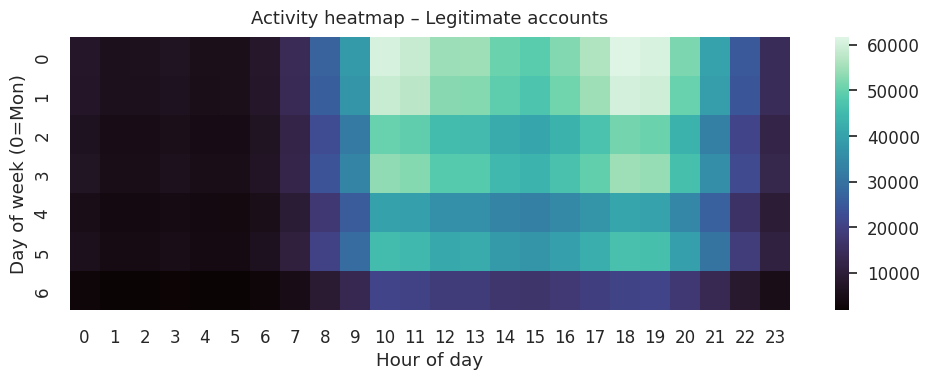

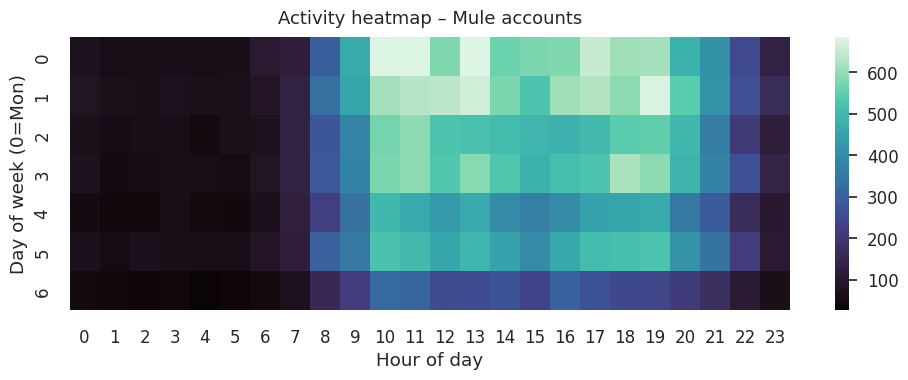

In [63]:
# =====================================
# 14. Temporal behaviour – DOW x Hour heatmaps
# =====================================
if transactions is not None:
    tx = transactions.merge(
        train_labels[["account_id", "is_mule"]],
        on="account_id", how="left"
    )
    tx["transaction_timestamp"] = pd.to_datetime(tx["transaction_timestamp"], errors="coerce")
    tx["dow"] = tx["transaction_timestamp"].dt.dayofweek
    tx["hour"] = tx["transaction_timestamp"].dt.hour

    for label_value, label_name in [(0, "Legitimate"), (1, "Mule")]:
        sub = tx[tx["is_mule"] == label_value]
        if sub.empty:
            continue
        pivot = (
            sub
            .groupby(["dow", "hour"])["transaction_id"]
            .nunique()
            .unstack(fill_value=0)
        )

        plt.figure(figsize=(10, 4))
        sns.heatmap(pivot, cmap="mako")
        plt.xlabel("Hour of day")
        plt.ylabel("Day of week (0=Mon)")
        set_ax_title(plt.gca(), f"Activity heatmap – {label_name} accounts")
        plt.tight_layout()
        plt.show()



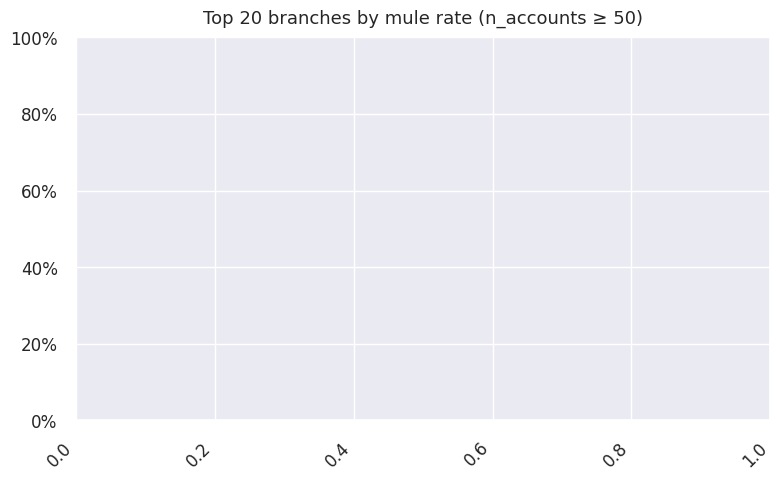

/tmp/ipython-input-3072463823.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x="rural_branch", y="is_mule", palette="viridis")


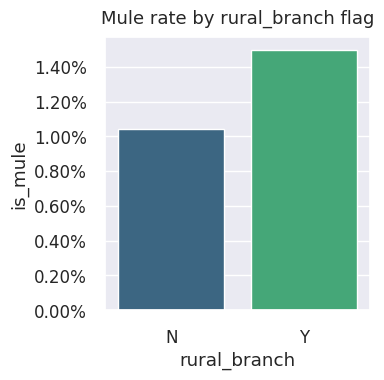

In [62]:
# =====================================
# 15. Branch-level & rural/urban patterns
# =====================================
if "branch_code" in accounts.columns:
    branch_df = (
        train_labels[["account_id", "is_mule"]]
        .merge(accounts[["account_id", "branch_code", "rural_branch"]], on="account_id", how="left")
    )
    branch_stats = (
        branch_df.groupby("branch_code")["is_mule"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mule_rate", "count": "n_accounts"})
    )

    large_branches = branch_stats[branch_stats["n_accounts"] >= 50].sort_values("mule_rate", ascending=False).head(20)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=large_branches.reset_index(),
        x="branch_code", y="mule_rate",
        palette="rocket"
    )
    format_percent_axis(plt.gca())
    plt.xticks(rotation=45, ha="right")
    set_ax_title(plt.gca(), "Top 20 branches by mule rate (n_accounts ≥ 50)")
    plt.tight_layout()
    plt.show()

if "rural_branch" in accounts.columns:
    rb = (
        train_labels[["account_id", "is_mule"]]
        .merge(accounts[["account_id", "rural_branch"]], on="account_id", how="left")
    )
    rate = rb.groupby("rural_branch")["is_mule"].mean().reset_index()

    plt.figure(figsize=(4, 4))
    sns.barplot(data=rate, x="rural_branch", y="is_mule", palette="viridis")
    format_percent_axis(plt.gca())
    set_ax_title(plt.gca(), "Mule rate by rural_branch flag")
    plt.tight_layout()
    plt.show()



In [59]:
# =====================================
# 16. Statistical tests: mule vs legit
# =====================================
test_features = [
    "avg_balance", "monthly_avg_balance", "account_age_days",
    "txn_count", "txn_velocity_per_day", "structuring_share",
    "unique_counterparties", "round_amount_share"
]
test_features = [c for c in test_features if c in train_txn.columns]

results = []
for col in test_features:
    mules = train_txn.loc[train_txn["is_mule"] == 1, col].dropna()
    legit = train_txn.loc[train_txn["is_mule"] == 0, col].dropna()
    if len(mules) == 0 or len(legit) == 0:
        continue
    stat, pval = stats.mannwhitneyu(mules, legit, alternative="two-sided")
    results.append({
        "feature": col,
        "n_mules": len(mules),
        "n_legit": len(legit),
        "median_mules": mules.median(),
        "median_legit": legit.median(),
        "p_value": pval
    })

results_df = pd.DataFrame(results).sort_values("p_value")
display(results_df)


,feature,n_mules,n_legit,median_mules,median_legit,p_value
6,unique_counterparties,258,23500,30.5000,10.0000,0.0000
5,structuring_share,258,23500,0.0104,0.0000,0.0000
7,round_amount_share,258,23500,0.1150,0.1678,0.0000
4,txn_velocity_per_day,253,23476,0.1005,0.0491,0.0000
3,txn_count,258,23500,67.5000,38.0000,0.0000
2,account_age_days,263,23760,751.0000,805.0000,0.0003
1,monthly_avg_balance,254,23044,"3,393.9600","5,213.9700",0.0498
0,avg_balance,254,23044,"3,560.9850","5,260.4400",0.0620


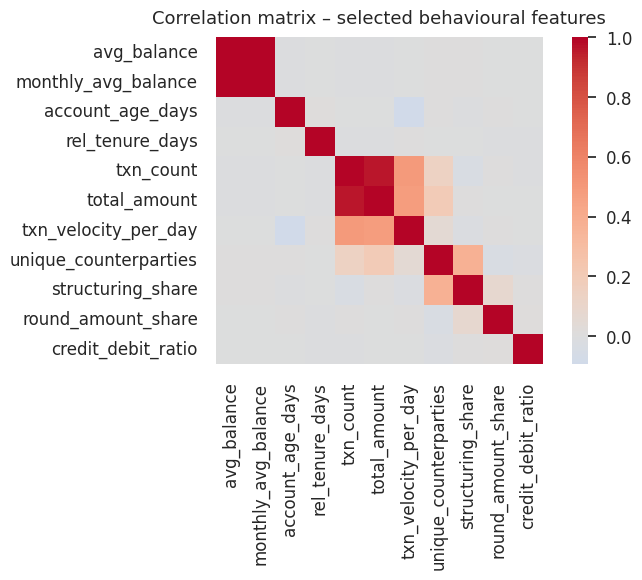

In [60]:
# =====================================
# 17. Focused correlation matrix for behavioural features
# =====================================
corr_cols = [
    "avg_balance", "monthly_avg_balance", "account_age_days", "rel_tenure_days",
    "txn_count", "total_amount", "txn_velocity_per_day",
    "unique_counterparties", "structuring_share", "round_amount_share", "credit_debit_ratio"
]
corr_cols = [c for c in corr_cols if c in train_txn.columns]

if len(corr_cols) > 1:
    corr_mat = train_txn[corr_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr_mat,
        cmap="coolwarm", center=0,
        annot=False, square=True
    )
    set_ax_title(plt.gca(), "Correlation matrix – selected behavioural features")
    plt.tight_layout()
    plt.show()


In [61]:
# =====================================
# 18. Data quality & leakage analysis
# =====================================
missing_rates = train_view.isna().mean().sort_values(ascending=False)
print("Top 25 columns by missingness in train_view:")
display(missing_rates.head(25))

leakage_cols = [
    c for c in ["mule_flag_date", "alert_reason", "flagged_by_branch"]
    if c in train_view.columns
]
print("Potential leakage columns present:", leakage_cols)

if leakage_cols:
    leak_df = pd.DataFrame({
        "column": leakage_cols,
        "non_null_mule": [
            train_view.loc[train_view["is_mule"] == 1, c].notna().mean()
            for c in leakage_cols
        ],
        "non_null_legit": [
            train_view.loc[train_view["is_mule"] == 0, c].notna().mean()
            for c in leakage_cols
        ],
    })
    display(leak_df)


Top 25 columns by missingness in train_view:


,0
alert_reason,0.9899
flagged_by_branch,0.9891
mule_flag_date,0.9891
unfreeze_date,0.9886
freeze_date,0.9641
last_mobile_update_date,0.8519
cc_sum,0.8422
loan_sum,0.7869
aadhaar_available,0.2410
pan_available,0.1430


Potential leakage columns present: ['mule_flag_date', 'alert_reason', 'flagged_by_branch']


,column,non_null_mule,non_null_legit
0,mule_flag_date,1.0000,0.0000
1,alert_reason,0.9202,0.0000
2,flagged_by_branch,1.0000,0.0000


In [64]:
# =====================================
# 19. Boss summary – univariate screening of candidate features
# =====================================

# Candidate numeric features to screen (add/remove as needed)
candidate_cols = [
    "avg_balance", "monthly_avg_balance", "quarterly_avg_balance", "daily_avg_balance",
    "account_age_days", "rel_tenure_days", "age_years",
    "txn_count", "total_amount", "avg_amount",
    "unique_counterparties", "txn_velocity_per_day",
    "structuring_share", "round_amount_share", "credit_debit_ratio",
    "days_since_last_txn"
]

candidate_cols = [c for c in candidate_cols if c in train_txn.columns]

rows = []
y = train_txn["is_mule"].values

for col in candidate_cols:
    s = train_txn[col]

    # Drop NaNs for tests
    mask = ~s.isna()
    x = s[mask].values
    y_sub = y[mask]

    # Class-wise medians
    m_mule = s[train_txn["is_mule"] == 1].median()
    m_legit = s[train_txn["is_mule"] == 0].median()

    # Mann–Whitney U test (non-parametric)
    try:
        mule_vals = s[train_txn["is_mule"] == 1].dropna()
        legit_vals = s[train_txn["is_mule"] == 0].dropna()
        if len(mule_vals) > 0 and len(legit_vals) > 0:
            stat, pval = stats.mannwhitneyu(mule_vals, legit_vals, alternative="two-sided")
        else:
            pval = np.nan
    except Exception:
        pval = np.nan

    # Point-biserial correlation (numeric vs binary target)
    try:
        r_pb, _ = stats.pointbiserialr(y_sub, x)
    except Exception:
        r_pb = np.nan

    rows.append({
        "feature": col,
        "median_mule": m_mule,
        "median_legit": m_legit,
        "median_diff": m_mule - m_legit,
        "median_ratio_mule_over_legit": (m_mule / m_legit) if (m_legit not in [0, np.nan]) else np.nan,
        "p_value_mannwhitney": pval,
        "-log10_p_value": -np.log10(pval) if pval not in [0, np.nan] else np.nan,
        "point_biserial_r": r_pb,
    })

feature_screen = (
    pd.DataFrame(rows)
    .sort_values(["p_value_mannwhitney", "-log10_p_value"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Top 20 strongest univariate signals vs is_mule:")
display(feature_screen.head(20))

# Save for use in the written feature-engineering plan
feature_screen.to_csv("feature_screening_summary.csv", index=False)
print("Saved univariate screening summary to feature_screening_summary.csv")


Top 20 strongest univariate signals vs is_mule:


,feature,median_mule,median_legit,median_diff,median_ratio_mule_over_legit,p_value_mannwhitney,-log10_p_value,point_biserial_r
0,unique_counterparties,30.5000,10.0000,20.5000,3.0500,0.0000,65.8701,0.1731
1,avg_amount,"14,845.2557","7,343.3463","7,501.9095",2.0216,0.0000,49.8660,0.0963
2,structuring_share,0.0104,0.0000,0.0104,NaN,0.0000,49.1914,0.0978
3,total_amount,"1,984,011.1150","311,301.1150","1,672,710.0000",6.3733,0.0000,35.5199,0.0284
4,round_amount_share,0.1150,0.1678,-0.0529,0.6850,0.0000,20.9107,-0.0410
5,txn_velocity_per_day,0.1005,0.0491,0.0514,2.0469,0.0000,14.6268,0.0001
6,txn_count,67.5000,38.0000,29.5000,1.7763,0.0000,10.6796,0.0016
7,account_age_days,751.0000,805.0000,-54.0000,0.9329,0.0003,3.5322,-0.0171
8,credit_debit_ratio,0.9733,0.8193,0.1540,1.1879,0.0012,2.9219,-0.0020
9,days_since_last_txn,38.5000,18.0000,20.5000,2.1389,0.0478,1.3203,0.0155


Saved univariate screening summary to feature_screening_summary.csv
